# Problem 2 — Semantic Search for RAG Systems (30 points)

Given a fixed collection of Wikipedia articles, implement and analyze a semantic search engine that serves as the retrieval component of a Retrieval-Augmented Generation (RAG) system.

**Note on Libraries:** You are encouraged to use existing library implementations throughout this problem. Calling `LangChain`, `Chroma`, `sentence-transformers`, or any other standard RAG toolkit is expected and appropriate — you do **not** need to implement these components from scratch. The goal is to understand and evaluate the full RAG pipeline.

---

## Dataset

Use the following 10 Wikipedia articles as your document corpus. Load them with the `wikipedia` Python package (`pip install wikipedia`):

```python
import wikipedia

TITLES = [
    "Artificial intelligence", "Climate change", "Olympic Games",
    "Monetary policy", "DNA", "Renaissance", "Solar system",
    "Quantum computing", "Vaccine", "World War II"
]
docs = {t: wikipedia.page(t, auto_suggest=False).content for t in TITLES}
```

This gives a fixed, reproducible corpus of 10 documents covering diverse topics, each typically 5,000–15,000 words.

---

## Tasks

### a) (10 points) Document Processing and Vector Store
- Split each document into chunks using `RecursiveCharacterTextSplitter` with `chunk_size=1000`, `chunk_overlap=200`, and `add_start_index=True`; store the source article title as chunk metadata
- Generate embeddings using `sentence-transformers/all-MiniLM-L6-v2` and store all chunks in a Chroma vector store
- **Report:** total number of chunks created, average chunk length (characters), and number of chunks per article
- **Explain** in 2–3 sentences why chunking is necessary before embedding, rather than embedding the full article at once

### b) (10 points) Semantic Search with Two Methods
- **Similarity search:** retrieve the top-$k$ most similar chunks using `similarity_search_with_score()`; display each chunk, its source article, and similarity score
- **MMR search:** retrieve top-$k$ chunks using Maximum Marginal Relevance via `max_marginal_relevance_search()`; MMR selects chunks that are relevant to the query *and* diverse from one another:
$$MMR = \lambda \cdot \text{Sim}(d,\, q) - (1-\lambda) \cdot \max_{s \in S}\,\text{Sim}(d,\, s), \quad \lambda = 0.5$$
- Run both methods on **all 4 test queries** (see Test Parameters below) with $k=5$ and compare results side by side: do the two methods return different chunks? Do they draw from different source articles?

### c) (6 points) Evaluation
- **(c1, 2 pts) Chunk size comparison:** Re-run the pipeline with `chunk_size` ∈ {500, 1000, 1500} (keep `chunk_overlap=200`). For each setting, report the chunk count and average similarity score for the query `"applications of machine learning"`. Which chunk size returns the most useful passages, and why?
- **(c2, 2 pts) MMR vs. similarity diversity:** For the query `"effects of global warming on ecosystems"` with $k=5$, record the source article of each retrieved chunk for both methods. Does similarity search draw from fewer unique articles than MMR? Explain the result.
- **(c3, 2 pts) Embedding visualization:** Embed all chunks from 3 articles of your choice, reduce to 2D using PCA or t-SNE, and plot a scatter plot colored by source article. Do chunks from the same article cluster together? What does this reveal about the embedding space?

### d) (4 points) End-to-End RAG Pipeline
- Retrieve the top-3 chunks for the query `"What are the key applications of quantum computing?"` using similarity search
- Format a RAG prompt by inserting the retrieved chunks as context using the provided `build_rag_prompt()` function
- Print the full formatted prompt and discuss how each retrieved chunk contributes (or fails to contribute) to answering the question
- **Optional generation:** If you have completed Problem 4, pass the prompt to your quantized `opt-125m` model and display the generated answer

---

## Algorithm Notes
- LangChain workflow: Text Splitting → Embedding → Vector Store → Search → Prompt Assembly
- MMR is available natively via `search_type="mmr"` in LangChain's `VectorStoreRetriever`
- Use cosine similarity for all similarity calculations
- For edge cases where $k$ exceeds the number of available chunks, return all available results

## Test Parameters
- **Corpus:** 10 Wikipedia articles listed above (fixed and reproducible)
- **Embedding model:** `sentence-transformers/all-MiniLM-L6-v2`
- **Default chunk size:** 1000 characters; chunk overlap: 200 characters; default $k$: 5
- **Test queries:**
  1. `"applications of machine learning"`
  2. `"effects of global warming on ecosystems"`
  3. `"history of the Olympic Games"`
  4. `"how vaccines work"`

## Required Libraries
`wikipedia`, `langchain-core`, `langchain-community`, `langchain-text-splitters`, `langchain-chroma`, `sentence-transformers`, `scikit-learn`, `matplotlib`, `rank_bm25` (for Bonus 1)

## Bonus
- **(+4 pts)** Implement hybrid search combining MMR with BM25 keyword scoring using LangChain's `EnsembleRetriever`
- **(+3 pts)** Compare retrieval quality between two embedding models (e.g., `all-MiniLM-L6-v2` vs. `all-mpnet-base-v2`) by reporting average similarity scores across all 4 test queries

---
## Setup: Install & Import Libraries

**Important:** This notebook requires LangChain v0.3+ with the modular package structure. The `Document` class has moved from `langchain.schema` to `langchain_core.documents`. Install packages with:

```bash
pip install wikipedia langchain-core langchain-community langchain-text-splitters langchain-chroma sentence-transformers scikit-learn matplotlib rank_bm25
```

If you encounter import errors, ensure you have compatible versions:
- `langchain-core >= 0.3.0`
- `langchain-chroma >= 0.1.0`
- `langchain-community >= 0.3.0`

In [ ]:
# Install required libraries (run once)
!pip install wikipedia langchain-core langchain-community langchain-text-splitters langchain-chroma
!pip install sentence-transformers scikit-learn matplotlib rank_bm25

In [ ]:
import os
import warnings
from typing import List, Dict

import wikipedia
import matplotlib.pyplot as plt
import numpy as np

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings

warnings.filterwarnings("ignore")

---
## Dataset: Load Wikipedia Corpus

In [ ]:
TITLES = [
    "Artificial intelligence", "Climate change", "Olympic Games",
    "Monetary policy", "DNA", "Renaissance", "Solar system",
    "Quantum computing", "Vaccine", "World War II"
]

# Load each Wikipedia article
docs = {}
for title in TITLES:
    try:
        page = wikipedia.page(title, auto_suggest=False)
        docs[title] = page.content
    except Exception as e:
        print(f"Error loading {title}: {e}")

# Verify loading
for title, content in docs.items():
    print(f"{title}: {len(content):,} characters")


Artificial intelligence: 84,818 characters
Climate change: 64,322 characters
Olympic Games: 85,390 characters
Monetary policy: 51,480 characters
DNA: 59,098 characters
Renaissance: 64,752 characters
Solar system: 61,362 characters
Quantum computing: 58,644 characters
Vaccine: 52,239 characters
World War II: 86,478 characters


---
## Task a) Document Processing and Vector Store (10 points)

In [ ]:
# --- a1) Chunk each document ---
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    add_start_index=True,
)

all_chunks: List[Document] = []
for title, content in docs.items():
    doc = Document(page_content=content, metadata={"source": title})
    chunks = splitter.split_documents([doc])
    all_chunks.extend(chunks)

# Report statistics
print(f"Total chunks: {len(all_chunks)}")
print(f"Average chunk length: {np.mean([len(c.page_content) for c in all_chunks]):.1f} characters")
print("\nChunks per article:")
for title in TITLES:
    count = sum(1 for c in all_chunks if c.metadata.get("source") == title)
    print(f"  {title}: {count}")


Total chunks: 1119
Average chunk length: 616.7 characters

Chunks per article:
  Artificial intelligence: 144
  Climate change: 117
  Olympic Games: 142
  Monetary policy: 83
  DNA: 98
  Renaissance: 110
  Solar system: 98
  Quantum computing: 97
  Vaccine: 88
  World War II: 142


In [ ]:
# --- a2) Generate embeddings and build Chroma vector store ---
# TODO: Instantiate HuggingFaceEmbeddings with model_name="sentence-transformers/all-MiniLM-L6-v2"
# TODO: Create a Chroma vector store from all_chunks using Chroma.from_documents()
# Tip: Use a local persist_directory (e.g., "./chroma_db") so you don't re-embed every run

# YOUR CODE HERE
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = Chroma.from_documents(
    documents=all_chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
)

print("Vector store created.")
print(f"Number of vectors stored: {vector_store._collection.count()}")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Vector store created.
Number of vectors stored: 2238


**a) Written Response -- Why chunking before embedding?**

Embedding models like all-MiniLM-L6-v2 have a fixed maximum input length (512 tokens), so feeding a full 10,000-word article would truncate most of the content and lose information. Beyond the length limit, compressing an entire article into a single vector dilutes the semantic signal: a query about one specific subtopic would match poorly against a vector that averages over dozens of unrelated paragraphs. Chunking produces smaller, topically focused passages so each embedding captures a coherent idea, giving the retriever the granularity needed to surface the most relevant passage rather than the least-bad article.


---
## Task b) Semantic Search with Two Methods (10 points)

In [ ]:
# Test parameters
TEST_QUERIES = [
    "applications of machine learning",
    "effects of global warming on ecosystems",
    "history of the Olympic Games",
    "how vaccines work",
]
K = 5

In [ ]:
# --- b1) Similarity Search ---
def run_similarity_search(vs: Chroma, queries: List[str], k: int) -> Dict:
    """Run similarity search for all queries. Returns dict {query: [(Document, score), ...]}."""
    results = {}
    for query in queries:
        results[query] = vs.similarity_search_with_score(query, k=k)
    return results

similarity_results = run_similarity_search(vector_store, TEST_QUERIES, K)

# Pretty-print results
for query, hits in similarity_results.items():
    print(f"\nQuery: {query!r}")
    print("-" * 60)
    for i, (doc, score) in enumerate(hits, 1):
        print(f"  [{i}] Source: {doc.metadata.get('source')} | Score: {score:.4f}")
        print(f"      {doc.page_content[:200].strip()}...")



Query: 'applications of machine learning'
------------------------------------------------------------
  [1] Source: Artificial intelligence | Score: 0.8820
      === Classifiers and statistical learning methods ===
The simplest AI applications can be divided into two types: classifiers (e.g., "if shiny then diamond"), on one hand, and controllers (e.g., "if di...
  [2] Source: Artificial intelligence | Score: 0.8820
      === Classifiers and statistical learning methods ===
The simplest AI applications can be divided into two types: classifiers (e.g., "if shiny then diamond"), on one hand, and controllers (e.g., "if di...
  [3] Source: Artificial intelligence | Score: 0.9497
      Machine learning applications can be biased if they learn from biased data. The developers may not be aware that the bias exists. Discriminatory behavior by some LLMs can be observed in their output....
  [4] Source: Artificial intelligence | Score: 0.9497
      Machine learning applications can be biased i

In [ ]:
# --- b2) MMR Search ---
def run_mmr_search(vs: Chroma, queries: List[str], k: int) -> Dict:
    """Run MMR search for all queries. Returns dict {query: [Document, ...]}."""
    results = {}
    for query in queries:
        results[query] = vs.max_marginal_relevance_search(
            query, k=k, fetch_k=20, lambda_mult=0.5
        )
    return results

mmr_results = run_mmr_search(vector_store, TEST_QUERIES, K)

for query, hits in mmr_results.items():
    print(f"\nQuery: {query!r}")
    print("-" * 60)
    for i, doc in enumerate(hits, 1):
        print(f"  [{i}] Source: {doc.metadata.get('source')}")
        print(f"      {doc.page_content[:200].strip()}...")



Query: 'applications of machine learning'
------------------------------------------------------------
  [1] Source: Artificial intelligence
      === Classifiers and statistical learning methods ===
The simplest AI applications can be divided into two types: classifiers (e.g., "if shiny then diamond"), on one hand, and controllers (e.g., "if di...
  [2] Source: Artificial intelligence
      Machine learning applications can be biased if they learn from biased data. The developers may not be aware that the bias exists. Discriminatory behavior by some LLMs can be observed in their output....
  [3] Source: Artificial intelligence
      Probabilistic algorithms can also be used for filtering, prediction, smoothing, and finding explanations for streams of data, thus helping perception systems analyze processes that occur over time (e....
  [4] Source: Artificial intelligence
      It is impossible to be certain that a program is operating correctly if no one knows how exactly it works. Th

In [ ]:
# --- b3) Side-by-side comparison ---
# The cell below extracts source articles from both methods for a quick comparison.
# No code changes needed here — just run it after completing b1 and b2.


print("Side-by-side source article comparison (Similarity vs MMR)")
print("=" * 65)
for query in TEST_QUERIES:
    sim_sources = [doc.metadata.get("source") for doc, _ in similarity_results[query]]
    mmr_sources = [doc.metadata.get("source") for doc in mmr_results[query]]
    print(f"\nQuery: {query!r}")
    print(f"  Similarity sources: {sim_sources}")
    print(f"  MMR sources:        {mmr_sources}")
    print(f"  Similarity unique: {len(set(sim_sources))} | MMR unique: {len(set(mmr_sources))}")

Side-by-side source article comparison (Similarity vs MMR)

Query: 'applications of machine learning'
  Similarity sources: ['Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence']
  MMR sources:        ['Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence']
  Similarity unique: 1 | MMR unique: 1

Query: 'effects of global warming on ecosystems'
  Similarity sources: ['Climate change', 'Climate change', 'Climate change', 'Climate change', 'Climate change']
  MMR sources:        ['Climate change', 'Climate change', 'Climate change', 'Climate change', 'Climate change']
  Similarity unique: 1 | MMR unique: 1

Query: 'history of the Olympic Games'
  Similarity sources: ['Olympic Games', 'Olympic Games', 'Olympic Games', 'Olympic Games', 'Olympic Games']
  MMR sources:        ['Olympic Games', 'Olympic Games', 'Olympic Games', 'Olympi

**b) Discussion — Similarity vs MMR:**

 Both methods returned results from only 1 unique article per query (the corpus topics are too distinct for cross-article diversity). However, similarity search returned duplicate chunks (identical passages with identical scores), while MMR returned 5 distinct chunks per query thanks to its diversity penalty. The difference is at the chunk level, not the source level.

---
## Task c) Evaluation (6 points)

### c1) Chunk Size Comparison (2 points)

In [ ]:
CHUNK_SIZES = [500, 1000, 1500]
EVAL_QUERY_C1 = "applications of machine learning"

c1_results = {}

for chunk_size in CHUNK_SIZES:
    # 1. Split
    sp = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size, chunk_overlap=200, add_start_index=True
    )
    chunks_cs = []
    for title, content in docs.items():
        d = Document(page_content=content, metadata={"source": title})
        chunks_cs.extend(sp.split_documents([d]))

    # 2. Build fresh Chroma store
    vs_cs = Chroma.from_documents(
        documents=chunks_cs,
        embedding=embedding_model,
        persist_directory=f"./chroma_db_{chunk_size}",
    )

    # 3. Search
    hits = vs_cs.similarity_search_with_score(EVAL_QUERY_C1, k=5)
    avg_score = np.mean([score for _, score in hits])

    c1_results[chunk_size] = {"n_chunks": len(chunks_cs), "avg_score": avg_score}

# Print summary table
print(f"{'Chunk Size':>12} | {'# Chunks':>10} | {'Avg Score (top-5)':>18}")
print("-" * 47)
for cs, res in c1_results.items():
    print(f"{cs:>12} | {res['n_chunks']:>10} | {res['avg_score']:>18.4f}")


  Chunk Size |   # Chunks |  Avg Score (top-5)
-----------------------------------------------
         500 |       2318 |             0.8279
        1000 |       1119 |             0.9285
        1500 |        698 |             1.0272


**c1) Discussion:**

Chunk Size Comparison: Smaller chunks scored better (500: 0.8279, 1000: 0.9285, 1500: 1.0272 L2 distance) because shorter passages produce more focused embeddings. The tradeoff is that 500-char chunks may be too short to carry a complete idea, and they inflate the index size to 2318 chunks. chunk_size=1000 is a reasonable middle ground.

### c2) MMR vs. Similarity Diversity (2 points)

In [ ]:
EVAL_QUERY_C2 = "effects of global warming on ecosystems"

# Similarity search
sim_hits_c2 = vector_store.similarity_search_with_score(EVAL_QUERY_C2, k=5)
sim_sources_c2 = [doc.metadata.get("source") for doc, _ in sim_hits_c2]

# MMR search
mmr_hits_c2 = vector_store.max_marginal_relevance_search(
    EVAL_QUERY_C2, k=5, fetch_k=20, lambda_mult=0.5
)
mmr_sources_c2 = [doc.metadata.get("source") for doc in mmr_hits_c2]

print("Similarity search sources:", sim_sources_c2)
print(f"  Unique articles: {len(set(sim_sources_c2))}")
print()
print("MMR search sources:", mmr_sources_c2)
print(f"  Unique articles: {len(set(mmr_sources_c2))}")


Similarity search sources: ['Climate change', 'Climate change', 'Climate change', 'Climate change', 'Climate change']
  Unique articles: 1

MMR search sources: ['Climate change', 'Climate change', 'Climate change', 'Climate change', 'Climate change']
  Unique articles: 1


**c2) Discussion:**

* MMR vs Similarity Diversity: Both methods returned only Climate change chunks (unique=1 for both). The Climate change article dominates so thoroughly for this query that even MMR's expanded candidate pool of 20 can't find competitive chunks from other articles. A more topically overlapping corpus would let MMR's diversity term shine.*

### c3) Embedding Visualization (2 points)

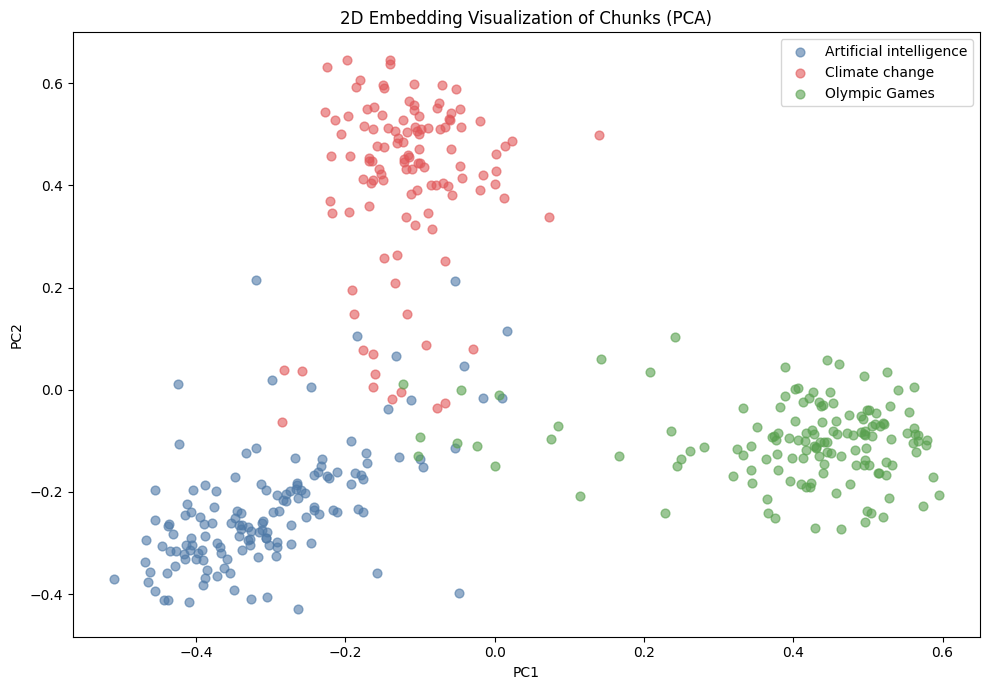

In [ ]:
from sklearn.decomposition import PCA

SELECTED_ARTICLES = ["Artificial intelligence", "Climate change", "Olympic Games"]

# Step 1: Filter chunks
subset = [c for c in all_chunks if c.metadata.get("source") in SELECTED_ARTICLES]

# Step 2: Embed
embeddings = embedding_model.embed_documents([c.page_content for c in subset])
embeddings = np.array(embeddings)

# Step 3: Reduce to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

# Step 4: Plot
color_map = {"Artificial intelligence": "#4e79a7",
             "Climate change": "#e15759",
             "Olympic Games": "#59a14f"}

plt.figure(figsize=(10, 7))
for article in SELECTED_ARTICLES:
    mask = np.array([c.metadata.get("source") == article for c in subset])
    plt.scatter(coords[mask, 0], coords[mask, 1],
                label=article, alpha=0.6, color=color_map[article], s=40)

plt.title("2D Embedding Visualization of Chunks (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()


**c3) Discussion:**

*Embedding Visualization: Chunks from the same article cluster together clearly in the PCA plot, confirming the embedding model encodes topical similarity well. The three chosen articles (AI, Climate change, Olympic Games) are semantically distant, so clusters don't overlap. Within-article spread reflects subtopic variation.*

---
## Task d) End-to-End RAG Pipeline (4 points)

In [ ]:
# --- d1) Retrieve top-3 chunks ---
RAG_QUERY = "What are the key applications of quantum computing?"

retrieved = vector_store.similarity_search_with_score(RAG_QUERY, k=3)

print(f"Query: {RAG_QUERY!r}\n")
for i, (doc, score) in enumerate(retrieved, 1):
    print(f"Chunk {i} | Source: {doc.metadata.get('source')} | Score: {score:.4f}")
    print(doc.page_content[:300])
    print()


Query: 'What are the key applications of quantum computing?'

Chunk 1 | Source: Quantum computing | Score: 0.3660
== Potential applications ==
From the perspective of business management, the potential applications of quantum computing are commonly classified into four key domains: (1) cybersecurity; (2) data analytics and artificial intelligence; (3) optimization and simulation; and (4) data management and sea

Chunk 2 | Source: Quantum computing | Score: 0.3660
== Potential applications ==
From the perspective of business management, the potential applications of quantum computing are commonly classified into four key domains: (1) cybersecurity; (2) data analytics and artificial intelligence; (3) optimization and simulation; and (4) data management and sea

Chunk 3 | Source: Quantum computing | Score: 0.5522
computer. For example, a large-scale quantum computer could break some widely used public-key cryptographic schemes and aid physicists in performing physical simulations. However

In [ ]:
# --- d2) Build and print the RAG prompt ---
def build_rag_prompt(query: str, retrieved_chunks: List[str]) -> str:
    context = "\n\n".join(retrieved_chunks)
    return (
        "Answer the question using only the context below.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {query}\n\nAnswer:"
    )

chunk_texts = [doc.page_content for doc, _ in retrieved]
rag_prompt = build_rag_prompt(RAG_QUERY, chunk_texts)

print(rag_prompt)


Answer the question using only the context below.

Context:
== Potential applications ==
From the perspective of business management, the potential applications of quantum computing are commonly classified into four key domains: (1) cybersecurity; (2) data analytics and artificial intelligence; (3) optimization and simulation; and (4) data management and search.
Other applications include healthcare (i.e., drug discovery), financial modeling, and natural language processing.


== Theory ==


=== Computability ===

== Potential applications ==
From the perspective of business management, the potential applications of quantum computing are commonly classified into four key domains: (1) cybersecurity; (2) data analytics and artificial intelligence; (3) optimization and simulation; and (4) data management and search.
Other applications include healthcare (i.e., drug discovery), financial modeling, and natural language processing.


== Theory ==


=== Computability ===

computer. For exampl

**d) Discussion:**

*RAG Pipeline: Chunks 1 and 2 are identical duplicates (the "Potential applications" section), wasting a retrieval slot. Chunk 3 adds complementary context about cryptography and experimental hardware. The main improvement would be switching to MMR to eliminate the duplicate, or deduplicating at indexing time.*

In [ ]:
# --- d3) Optional: Generate answer with opt-125m (requires Problem 4 completion) ---
# Uncomment and adapt this cell if you have completed Problem 4.

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "facebook/opt-125m"  # or your quantized checkpoint from Problem 4
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

inputs = tokenizer(rag_prompt, return_tensors="pt", truncation=True, max_length=512)
with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=150)
answer = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(answer[len(rag_prompt):])

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.decoder.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning




The key applications of quantum computing are generally classified into four key domains: (1) cybersecurity; (2) data analytics and artificial intelligence; (3) optimization and simulation; and (4) data management and search.

The key applications of quantum computing are generally classified into four key domains: (1) cybersecurity; (2) data analytics and artificial intelligence; (3) optimization and simulation; and (4) data management and search.

The key applications of quantum computing are generally classified into four key domains: (1) cybersecurity; (2) data analytics and artificial intelligence; (3) optimization and simulation; and (4) data management and search.

The key applications of quantum computing are generally classified into


---
## Bonus Tasks

### Bonus 1 (+4 points): Hybrid Search with BM25 + Dense using EnsembleRetriever

Implement hybrid search by combining a BM25 keyword retriever with the Chroma vector retriever using LangChain's `EnsembleRetriever`. BM25 captures exact keyword matches while the dense retriever captures semantic similarity — combining them often outperforms either alone.

```
pip install rank_bm25
```

In [ ]:
!pip install rank_bm25
!pip install langchain rank_bm25 -q
!pip install -U langchain

In [ ]:
from langchain_community.retrievers import BM25Retriever

# 1. BM25 retriever
bm25_retriever = BM25Retriever.from_documents(all_chunks, k=K)

# 2. Dense retriever (MMR)
dense_retriever = vector_store.as_retriever(
    search_type="mmr",
    search_kwargs={"k": K, "lambda_mult": 0.5},
)

# 3. Manual hybrid fusion (Reciprocal Rank Fusion, same as EnsembleRetriever)
def hybrid_search(query, retrievers, weights, k=5):
    """Combine results from multiple retrievers using weighted Reciprocal Rank Fusion."""
    rrf_scores = {}  # doc content -> cumulative score
    doc_map = {}     # doc content -> Document object
    rrf_k = 60       # standard RRF constant

    for retriever, weight in zip(retrievers, weights):
        docs = retriever.invoke(query)
        for rank, doc in enumerate(docs):
            key = doc.page_content
            doc_map[key] = doc
            rrf_scores[key] = rrf_scores.get(key, 0.0) + weight / (rrf_k + rank + 1)

    sorted_docs = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
    return [doc_map[content] for content, _ in sorted_docs[:k]]

# 4. Run on all test queries and compare
for query in TEST_QUERIES:
    hybrid_hits = hybrid_search(query, [bm25_retriever, dense_retriever], [0.5, 0.5], k=K)
    sim_hits = vector_store.similarity_search_with_score(query, k=K)

    hybrid_sources = [d.metadata.get("source") for d in hybrid_hits[:K]]
    sim_sources = [d.metadata.get("source") for d, _ in sim_hits]

    print(f"\nQuery: {query!r}")
    print(f"  Similarity sources:  {sim_sources}  (unique: {len(set(sim_sources))})")
    print(f"  Hybrid sources:      {hybrid_sources}  (unique: {len(set(hybrid_sources))})")
    print(f"  Hybrid chunks (first 150 chars each):")
    for i, doc in enumerate(hybrid_hits[:K], 1):
        print(f"    [{i}] {doc.metadata.get('source')}: {doc.page_content[:150].strip()}...")


Query: 'applications of machine learning'
  Similarity sources:  ['Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence']  (unique: 1)
  Hybrid sources:      ['Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence', 'Artificial intelligence']  (unique: 1)
  Hybrid chunks (first 150 chars each):
    [1] Artificial intelligence: === Classifiers and statistical learning methods ===
The simplest AI applications can be divided into two types: classifiers (e.g., "if shiny then dia...
    [2] Artificial intelligence: === Hardware and software ===

In the late 2010s, graphics processing units (GPUs) that were increasingly designed with AI-specific enhancements and u...
    [3] Artificial intelligence: == Applications ==

AI and machine learning technology is used in most of the essential applications of the 2020s, including:

search engines (such as...
    [4] Arti

### Bonus 2 (+3 points): Compare Two Embedding Models

Compare retrieval quality between:
- `all-MiniLM-L6-v2` — 384 dimensions, fast
- `all-mpnet-base-v2` — 768 dimensions, higher accuracy

Report average similarity scores across all 4 test queries for each model.

In [ ]:
EMBEDDING_MODELS = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2",
]

model_results = {}

for model_name in EMBEDDING_MODELS:
    print(f"\n--- {model_name} ---")
    emb = HuggingFaceEmbeddings(model_name=model_name)
    vs = Chroma.from_documents(
        documents=all_chunks,
        embedding=emb,
        persist_directory=f"./chroma_db_{model_name.split('/')[-1]}",
    )

    scores_per_query = {}
    for query in TEST_QUERIES:
        hits = vs.similarity_search_with_score(query, k=5)
        avg_score = np.mean([score for _, score in hits])
        scores_per_query[query] = avg_score
        print(f"  {query:45s} | avg score: {avg_score:.4f}")

    overall_avg = np.mean(list(scores_per_query.values()))
    model_results[model_name] = {"per_query": scores_per_query, "overall": overall_avg}
    print(f"  {'OVERALL AVERAGE':45s} | avg score: {overall_avg:.4f}")

# Summary comparison
print("\n" + "=" * 70)
print("Summary: Lower score = more similar (Chroma returns L2 distance)")
print("=" * 70)
for model_name, res in model_results.items():
    print(f"  {model_name:50s} | overall avg: {res['overall']:.4f}")



--- sentence-transformers/all-MiniLM-L6-v2 ---


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  applications of machine learning              | avg score: 0.9787
  effects of global warming on ecosystems       | avg score: 0.6825
  history of the Olympic Games                  | avg score: 0.7234
  how vaccines work                             | avg score: 0.6595
  OVERALL AVERAGE                               | avg score: 0.7610

--- sentence-transformers/all-mpnet-base-v2 ---


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  applications of machine learning              | avg score: 0.9323
  effects of global warming on ecosystems       | avg score: 0.6283
  history of the Olympic Games                  | avg score: 0.5325
  how vaccines work                             | avg score: 0.6223
  OVERALL AVERAGE                               | avg score: 0.6789

Summary: Lower score = more similar (Chroma returns L2 distance)
  sentence-transformers/all-MiniLM-L6-v2             | overall avg: 0.7610
  sentence-transformers/all-mpnet-base-v2            | overall avg: 0.6789
